
# Анализ стоимости упаковочных материалов и себестоимость заказа WrapItUp

Цель этой части - оценить себестоимость услуги WrapItUp с учётом стоимости упаковочных материалов и затрат на персонал и сравненить себестоимость с ценами на похожие услуги

В анализе используются:
- динамический парсинг сайта Leonardo для оценки стоимости упаковочных материалов;
- ручной сбор цен сервисов подарочной упаковки;
- расчёт себестоимости одного заказа;
- сравнение себестоимости с рыночными ценами на схожие сервисы.


In [1]:
!pip install playwright
!playwright install chromium
!playwright install-deps chromium


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 MB 17.3 MB/s eta 0:00:00
175.4 MiB [] 0% 0.0s175.4 MiB [] 0% 38.7s175.4 MiB [] 0% 15.8s175.4 MiB [] 0% 13.9s175.4 MiB [] 0% 7.0s175.4 MiB [] 1% 5.2s175.4 MiB [] 2% 5.3s175.4 MiB [] 2% 5.1s175.4 MiB [] 3% 4.7s175.4 MiB [] 3% 5.1s175.4 MiB [] 3% 5.4s175.4 MiB [] 3% 5.1s175.4 MiB [] 4% 4.5s175.4 MiB [] 5% 4.2s175.4 MiB [] 5% 3.9s175.4 MiB [] 6% 3.7s175.4 MiB [] 7% 3.6s175.4 MiB [] 7% 4.2s175.4 MiB [] 8% 4.0s175.4 MiB [] 9% 3.6s175.4 MiB [] 11% 3.2s175.4 MiB [] 12% 3.1s175.4 MiB [] 13% 2.9s175.4 MiB [] 14% 2.8s175.4 MiB [] 14% 3.0s175.4 MiB [] 15% 2.9s175.4 MiB [] 16% 2.8s175.4 MiB [] 17% 2.7s175.4 MiB [] 18% 2.6s175.4 MiB [] 19% 2.5s175.4 MiB [] 20% 2.5s175.4 MiB [] 21% 2.4s175.4 MiB [] 21% 2.5s175.4 MiB [] 21% 2.6s175.4 MiB [] 22% 2.6s175.4 MiB [] 23% 2.5s175.4 MiB [] 24% 2.4s175.4 MiB [] 25% 2.3s175.4 MiB [] 26% 2.3s175.4 MiB [] 26% 2.2s175.4 MiB [] 27% 2.1s175.4 MiB [] 28% 2.1s175.4 MiB [] 29% 2.0s175.4 MiB [] 31% 1.9s175.4 MiB [] 3

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from playwright.async_api import async_playwright


In [3]:
async def get_page_text_dynamic(url):
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True, args=["--no-sandbox", "--disable-dev-shm-usage"])
        page = await browser.new_page(user_agent="Mozilla/5.0")
        await page.goto(url, wait_until="domcontentloaded", timeout=60000)
        await page.wait_for_timeout(5000)
        text = await page.inner_text("body")
        await browser.close()
    return text


In [4]:
def parse_leonardo_products(text, material_type, url, max_items=20):
    lines = [line.strip() for line in text.split("\n") if line.strip()]
    products = []
    for i, line in enumerate(lines):
        if re.fullmatch(r"\d[\d\s]*₽", line):
            price = int(line.replace("₽", "").replace(" ", ""))
            if i + 1 < len(lines) and 10 <= price <= 5000:
                products.append({"material_type": material_type, "product_name": lines[i + 1], "price": price, "source": "leonardo.ru", "url": url})
        if len(products) >= max_items:
            break
    return products


In [5]:
material_urls = {
    "подарочная коробка": "https://leonardo.ru/ishop/?search=подарочная%20коробка",
    "упаковочная бумага": "https://leonardo.ru/ishop/?search=упаковочная%20бумага",
    "лента": "https://leonardo.ru/ishop/?search=лента%20атласная"}


In [6]:
materials_data = []

try:
    for material_type, url in material_urls.items():
        text = await get_page_text_dynamic(url)
        products = parse_leonardo_products(text=text, material_type=material_type, url=url, max_items=20)
        materials_data.extend(products)
    materials_df = pd.DataFrame(materials_data)
    if materials_df.empty:
        materials_df = pd.read_csv("materials_prices.csv")
except Exception as error:
    print("Данные не удалось загрузить динамически, поэтому используется сохранённый CSV:", error)
    materials_df = pd.read_csv("materials_prices.csv")

materials_df.head()


,material_type,product_name,price,source,url
0,подарочная коробка,"""Stilerra"" SBOX-SKP1-10/9 Крафт-коробка подаро...",429,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
1,подарочная коробка,"""Stilerra"" SBOX-SKP1-10/8 Крафт-коробка подаро...",379,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
2,подарочная коробка,"""Stilerra"" SBOX-SKP1-10/7 Крафт-коробка подаро...",300,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
3,подарочная коробка,"""Stilerra"" SBOX-SKP1-10/3 Крафт-коробка подаро...",129,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
4,подарочная коробка,"""Stilerra"" SBOX-SKP1-10/6 Крафт-коробка подаро...",250,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...


In [7]:
materials_df["material_type"].value_counts()


,count
material_type,
подарочная коробка,20
упаковочная бумага,20
лента,20


In [8]:
material_urls["лента"] = "https://leonardo.ru/ishop/lenty-atlasnye/"


In [9]:
try:
    text_lenta = await get_page_text_dynamic(material_urls["лента"])
except Exception as error:
    text_lenta = ""
    print("Страница лент не загрузилась:", error)

print(text_lenta[:3000])
print("Есть ₽:", "₽" in text_lenta)
print("Есть лента:", "лента" in text_lenta.lower())


Адрес
Поиск
Профиль
Избранное
Корзина
КАТАЛОГ
МАГАЗИНЫ
МАСТЕР-КЛАССЫ В МАГАЗИНАХ
ОНЛАЙН-МАСТЕРСКАЯ
АКЦИИ
БРЕНДЫ
Шитье/Ленты для шитья/Ленты декоративные/Атласные
Ленты атласные

45 товаров

Атласные
Бархатные
Гипюр
Джутовые
Жаккардовые
Капроновые
Кружевные
Металлизированные
Наборы
Орденские
Репсовые
Тесьма вьюнчик
Хлопковые
Шелковые
Шитье
Наличие в магазинах
ТРЦ Спектр 39
Мытищи, ТРК Красный кит 39
ТРЦ Серебряный дом 39
ТРЦ Каширская плаза 37
ТРЦ Город на Рязанке 36
ТРЦ Саларис 36
ТЦ Александр Лэнд 35
Все
Особенности доставки
Самовывоз сегодня 45
Цена
от
до
Товары со скидкой
Да 2
Тип товара
Сбросить параметр
Воротник
Вставка
Кружево
Лента 45
Набор 2
Тесьма
Вид ленты
Сбросить параметр
Зиг-заг 17
Атласная 45
Бархатная 10
Бахрома 3
Без рисунка 1
Вязаная 8
Гипюр 179
Все
Вид товара
Окантовочная
С пайетками
Состав
Акрил
Вискоза
Джут
Лён
Метанит
Нейлон
Полиамид
Полиэстер 44
Полиэтилен 5
Полиэфир 1
Все
Цвет
Ассорти 2
Белый 22
Разноцветные 33
Чёрный 18
Бежевый 10
Бирюзовый 4
Бордовый 7
Все
Коли

Первые разы парсинг был удачный, но после десятков перезапусков, данные перестали хорошо извлекаться. Поэтому достанем данные из сохраненной таблицы с первых парсингов.
(в этой версии он сработал, но я все равно оставлю через файл, слишком много раз уже переделывала...)

In [10]:
materials_df = pd.read_csv("materials_prices.csv")
materials_df.head()


,material_type,product_name,price,source,url
0,подарочная коробка,"""Stilerra"" SBOX-SKP1-10/9 Крафт-коробка подаро...",429,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
1,подарочная коробка,"""Stilerra"" SBOX-SKP1-10/8 Крафт-коробка подаро...",379,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
2,подарочная коробка,"""Stilerra"" SBOX-SKP1-10/7 Крафт-коробка подаро...",300,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
3,подарочная коробка,"""Stilerra"" SBOX-SKP1-10/3 Крафт-коробка подаро...",129,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
4,подарочная коробка,"""Stilerra"" SBOX-SKP1-10/6 Крафт-коробка подаро...",250,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...


In [11]:
materials_clean = materials_df.copy()
mask_box_pack = materials_clean["material_type"].eq("подарочная коробка") & materials_clean["product_name"].str.contains("132 ₽ х 4", regex=False, na=False)
materials_clean.loc[mask_box_pack, "price"] = 132


In [12]:
mask_lenta_discount = materials_clean["material_type"].eq("лента") & materials_clean["product_name"].str.contains(r"^\s*-\d+%\s*$", regex=True, na=False)
materials_clean = materials_clean[~mask_lenta_discount].copy()
materials_clean[materials_clean["material_type"].eq("подарочная коробка")].sort_values("price", ascending=False)


,material_type,product_name,price,source,url
0,подарочная коробка,"""Stilerra"" SBOX-SKP1-10/9 Крафт-коробка подаро...",429,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
1,подарочная коробка,"""Stilerra"" SBOX-SKP1-10/8 Крафт-коробка подаро...",379,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
2,подарочная коробка,"""Stilerra"" SBOX-SKP1-10/7 Крафт-коробка подаро...",300,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
4,подарочная коробка,"""Stilerra"" SBOX-SKP1-10/6 Крафт-коробка подаро...",250,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
14,подарочная коробка,"""Stilerra"" SBOX-SKN4-10/5 Крафт-коробка подаро...",239,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
15,подарочная коробка,"""Stilerra"" SBOX-SKN4-10/5 Крафт-коробка подаро...",239,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
16,подарочная коробка,"""Stilerra"" SBOX-SKN4-10/4 Крафт-коробка подаро...",209,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
17,подарочная коробка,"""Stilerra"" SBOX-SKN4-10/4 Крафт-коробка подаро...",209,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
9,подарочная коробка,"""Stilerra"" SBOX-SKP1-10/5 Крафт-коробка подаро...",179,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...
10,подарочная коробка,"""Stilerra"" SBOX-SKN4-10/3 Крафт-коробка подаро...",169,leonardo.ru,https://leonardo.ru/ishop/?search=подарочная%2...


In [13]:
materials_stats = materials_clean.groupby("material_type")["price"].agg(count="count", mean_price="mean", median_price="median", min_price="min", max_price="max").round(3)
materials_stats


,count,mean_price,median_price,min_price,max_price
material_type,,,,,
лента,13,127.462,99.0,69,249
подарочная коробка,20,192.850,169.0,79,429
упаковочная бумага,20,183.000,179.0,119,389


In [14]:
box_cost = 169
paper_roll_price = 179
paper_uses = 2
paper_cost_per_order = paper_roll_price / paper_uses
ribbon_roll_price = 99
ribbon_uses = 15
ribbon_cost_per_order = ribbon_roll_price / ribbon_uses
materials_cost_per_order = box_cost + paper_cost_per_order + ribbon_cost_per_order
materials_cost_per_order


265.1

In [15]:
staff_cost_per_order = 910
total_cost_per_order = staff_cost_per_order + materials_cost_per_order
total_cost_per_order


1175.1

 Цены на услуги подарочной упаковки

Прямых аналогов WrapItUp нет, так как найденные сервисы оказывают только услугу упаковки без забирания товара с маркетплейса и доставки до получателя. Тем не менее их цены можно использовать как ориентир рынка подарочной упаковки.


In [16]:
services_df = pd.DataFrame([
    ["opakovali.online", "20x20 подарок", 1020],
    ["opakovali.online", "30x30 подарок", 1710],
    ["opakovali.online", "40x40 подарок", 2510],
    ["aflowermoskva", "упаковка M", 950],
    ["aflowermoskva", "упаковка L", 1300],
    ["moi-tvoi", "дизайн 1", 650],
    ["moi-tvoi", "дизайн 2", 570],
    ["moi-tvoi", "дизайн 3", 620],
    ["moi-tvoi", "дизайн 4", 700]], columns=["source", "service", "price"])
services_df


,source,service,price
0,opakovali.online,20x20 подарок,1020
1,opakovali.online,30x30 подарок,1710
2,opakovali.online,40x40 подарок,2510
3,aflowermoskva,упаковка M,950
4,aflowermoskva,упаковка L,1300
5,moi-tvoi,дизайн 1,650
6,moi-tvoi,дизайн 2,570
7,moi-tvoi,дизайн 3,620
8,moi-tvoi,дизайн 4,700


In [17]:
services_stats = services_df["price"].agg(["mean", "median", "min", "max"]).round(3)
services_stats


,price
mean,1114.444
median,950.000
min,570.000
max,2510.000


Сравнение себестоимости с рыночными ценами


In [18]:
services_df["estimated_profit"] = services_df["price"] - total_cost_per_order
services_df["profitability"] = services_df["estimated_profit"].apply(lambda x: "прибыль" if x > 0 else "убыток")
services_df


,source,service,price,estimated_profit,profitability
0,opakovali.online,20x20 подарок,1020,-155.1,убыток
1,opakovali.online,30x30 подарок,1710,534.9,прибыль
2,opakovali.online,40x40 подарок,2510,1334.9,прибыль
3,aflowermoskva,упаковка M,950,-225.1,убыток
4,aflowermoskva,упаковка L,1300,124.9,прибыль
5,moi-tvoi,дизайн 1,650,-525.1,убыток
6,moi-tvoi,дизайн 2,570,-605.1,убыток
7,moi-tvoi,дизайн 3,620,-555.1,убыток
8,moi-tvoi,дизайн 4,700,-475.1,убыток


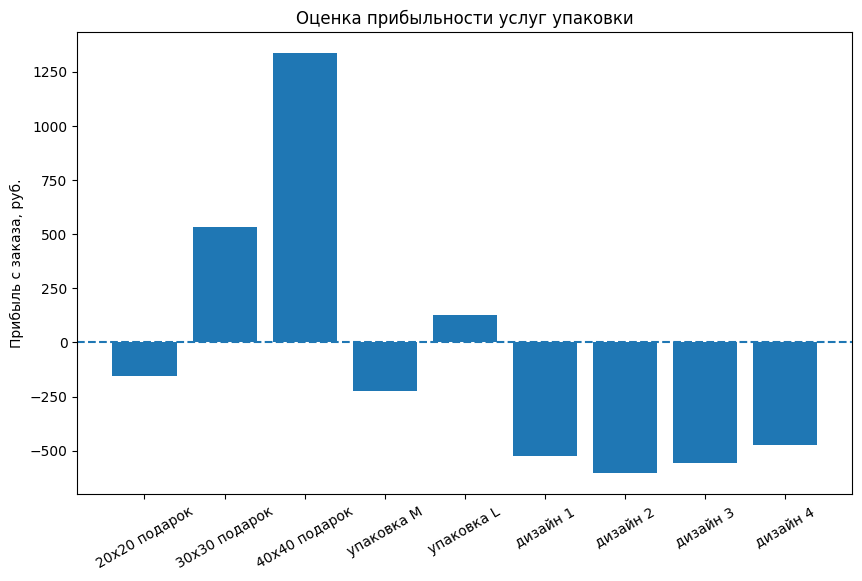

In [19]:
plt.figure(figsize=(10, 6))
plt.bar(services_df["service"], services_df["estimated_profit"])
plt.axhline(0, linestyle="--")
plt.xticks(rotation=30)
plt.ylabel("Прибыль с заказа, руб.")
plt.title("Оценка прибыльности услуг упаковки")
plt.show()


In [20]:
cost_structure_df = pd.DataFrame([["персонал", staff_cost_per_order], ["материалы", materials_cost_per_order]], columns=["cost_type", "cost"])
cost_structure_df


,cost_type,cost
0,персонал,910.0
1,материалы,265.1


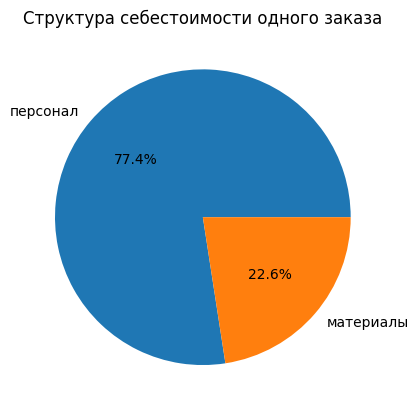

In [21]:
cost_structure_df.plot(kind="pie", y="cost", labels=cost_structure_df["cost_type"], autopct="%1.1f%%", legend=False)
plt.title("Структура себестоимости одного заказа")
plt.ylabel("")
plt.show()


#Выводы

Сравнение с рынком показывает, что услуги простейшей упаковки, за 570–700 руб. не покрывают полную себестоимость WrapItUp. Это объясняется тем, что технологическая цепочка WrapItUp включает не только упаковку, но и получение товара, обработку заказа и доставку клиенту.

Наиболее жизнеспособной выглядит модель премиального или комплексного сервиса:
- упаковка крупных или нестандартных подарков;
- подарки «под ключ»;
- корпоративные заказы;
- упаковка с доставкой в заданном интервале.

Следовательно, проекту не стоит конкурировать только с дешёвыми услугами упаковки. Более логичное позиционирование — комплексный сервис с соответствующей стоимостью.
